# 1.Wprowadzenie

**Energia** odgrywa fundamentalną rolę we współczesnych społeczeństwach, wpływając na **rozwój gospodarczy**, **wzrost przemysłu** oraz **jakość życia**. Jednocześnie rosnące zapotrzebowanie na energię i coraz większa świadomość zmian klimatu przyspieszyły globalną transformację od **paliw kopalnych** do **odnawialnych źródeł energii**. Zrozumienie długoterminowych wzorców zużycia energii oraz zmian w miksie energetycznym jest więc niezbędne do oceny obecnej polityki energetycznej i przyszłych wyzwań związanych ze zrównoważonym rozwojem.

Zbiór danych analizowany w tym projekcie opiera się na bazie **World Energy Consumption** utrzymywanej przez *Our World in Data* i udostępnianej przez **Kaggle**. Zawiera on roczne obserwacje dla krajów i regionów z całego świata, obejmujące szeroki zakres wskaźników związanych z:

- zużyciem energii,
- produkcją energii elektrycznej,
- produkcją energii,
- paliwami kopalnymi,
- odnawialnymi źródłami energii,
- emisją dwutlenku węgla,
- rozwojem gospodarczym.

Zbiór danych obejmuje **wiele dekad**, dzięki czemu nadaje się do badania **długoterminowych trendów** i **porównań między krajami**.

Celem tej analizy jest zbadanie, jak **zużycie energii zmieniało się w czasie** oraz jak różni się **skład źródeł energii** w poszczególnych krajach. Szczególna uwaga poświęcona jest przejściu od **paliw kopalnych** do **odnawialnych źródeł energii**, a także relacji między zużyciem energii a wybranymi wskaźnikami społeczno-ekonomicznymi.

> Głównym założeniem projektu jest pokazanie zmian w strukturze wykorzystania energii oraz wskazanie różnic pomiędzy krajami.

Analiza rozpoczyna się od **czyszczenia i przygotowania danych**, aby zapewnić ich spójność i wiarygodność. Następnie wykorzystuje się **analizę eksploracyjną** i **wizualizacje** do identyfikacji trendów, porównywania krajów oraz badania zmian w globalnym krajobrazie energetycznym. Na końcu wyniki są interpretowane, aby dostarczyć wniosków na temat ostatnich zmian w światowym zużyciu energii i ich potencjalnych konsekwencji.

# 2.Czyszczenie i porządkowanie danych

In [21]:
# Import necessary libraries
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

In [22]:
# Loading the dataset
data = pd.read_csv('../data/raw/owid-energy-data.csv')

In [23]:
# Displaying basic information about the dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 23195 entries, 0 to 23194
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), str(2)
memory usage: 23.0 MB


In [24]:
# Checking for missing values in the dataset
data.isna().sum()

country                       0
year                          0
iso_code                   6096
population                 4466
gdp                       11415
                          ...  
wind_elec_per_capita      14894
wind_electricity          13324
wind_energy_per_capita    18050
wind_share_elec           15327
wind_share_energy         16816
Length: 130, dtype: int64

In [25]:
# Displaying basic statistics of the dataset
data.describe()

,year,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
count,23195.000000,1.872900e+04,1.178000e+04,2070.000000,7903.000000,6338.000000,8057.000000,5753.000000,6063.000000,6040.000000,...,7940.000000,6379.000000,2798.000000,6293.000000,6405.000000,8301.000000,9871.000000,5145.000000,7868.000000,6379.000000
mean,1975.859280,1.010849e+08,4.257565e+11,43.478804,1.054261,55.157858,15.092054,69.409590,12.252558,1.939152,...,0.902081,0.219802,290.408294,6.021235,48.691257,63.651510,18.589892,214.960358,1.521953,0.518141
std,35.207901,4.606079e+08,3.507870e+12,286.672317,6.641947,180.665240,75.942529,199.403432,52.276644,5.339924,...,2.775481,0.766125,6070.498582,34.260028,281.755752,259.959746,114.342308,733.884486,4.619313,1.722172
min,1900.000000,1.733000e+03,1.642060e+08,-100.000000,-59.084000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-100.000000,-46.535000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1949.000000,1.596265e+06,1.426394e+10,-0.968000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,2.329000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1985.000000,6.875000e+06,4.357680e+10,6.695500,0.000000,0.000000,0.000000,0.793000,0.020000,0.148500,...,0.000000,0.000000,18.349500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2005.000000,2.531192e+07,1.830576e+11,23.320750,0.000000,0.506750,0.062000,42.905000,0.860000,1.601000,...,0.200000,0.006000,45.210750,0.096000,0.916000,1.695000,0.090000,25.914000,0.473250,0.074500
max,2024.000000,8.161972e+09,1.301126e+14,6373.062000,144.290000,2587.921000,1366.878000,2450.813000,712.160000,77.586000,...,50.000000,9.881000,242384.859000,642.617000,6124.465000,3850.312000,2497.250000,9315.340000,57.913000,26.085000


In [26]:
# Selecting relevant columns for analysis
cols = [
    "country", "year", "iso_code", "population", "gdp",
    "energy_consumption", "energy_per_capita",
    "electricity_generation", "electricity_demand",
    "coal_share_energy", "oil_share_energy", "gas_share_energy",
    "renewables_share_energy"
]
cols = [c for c in cols if c in data.columns]
data = data[cols]

data = data.rename(columns={
    "country": "kraj",
    "year": "rok",
    "iso_code": "kod_iso",
    "population": "populacja",
    "gdp": "pkb",
    "energy_consumption": "zuzycie_energii",
    "energy_per_capita": "energia_na_osobe",
    "electricity_generation": "produkcja_energii_elektrycznej",
    "electricity_demand": "zapotrzebowanie_na_energie_elektryczna",
    "coal_share_energy": "udzial_wegla_w_energii",
    "oil_share_energy": "udzial_ropy_w_energii",
    "gas_share_energy": "udzial_gazu_w_energii",
    "renewables_share_energy": "udzial_energii_odnawialnej"
})

countries = data[data["kod_iso"].notna()].copy()
countries = countries[countries["kraj"] != "ASEAN (Ember)"]
countries = countries.drop_duplicates(subset=["kraj", "rok"])

basic = countries[["kraj", "rok", "populacja", "pkb", "energia_na_osobe"]].copy()
electricity = countries[["kraj", "rok", "produkcja_energii_elektrycznej", "zapotrzebowanie_na_energie_elektryczna"]].copy()
mix = countries[["kraj", "rok", "udzial_wegla_w_energii", "udzial_ropy_w_energii", "udzial_gazu_w_energii", "udzial_energii_odnawialnej"]].copy()

In [27]:
# Displaying information about the selected datasets
basic.info()
electricity.info()
mix.info()

<class 'pandas.DataFrame'>
Index: 17099 entries, 25 to 23194
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   kraj              17099 non-null  str    
 1   rok               17099 non-null  int64  
 2   populacja         16996 non-null  float64
 3   pkb               11559 non-null  float64
 4   energia_na_osobe  10298 non-null  float64
dtypes: float64(3), int64(1), str(1)
memory usage: 801.5 KB
<class 'pandas.DataFrame'>
Index: 17099 entries, 25 to 23194
Data columns (total 4 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   kraj                                    17099 non-null  str    
 1   rok                                     17099 non-null  int64  
 2   produkcja_energii_elektrycznej          6353 non-null   float64
 3   zapotrzebowanie_na_energie_elektryczna  5479 non-null   float64
dtypes: flo

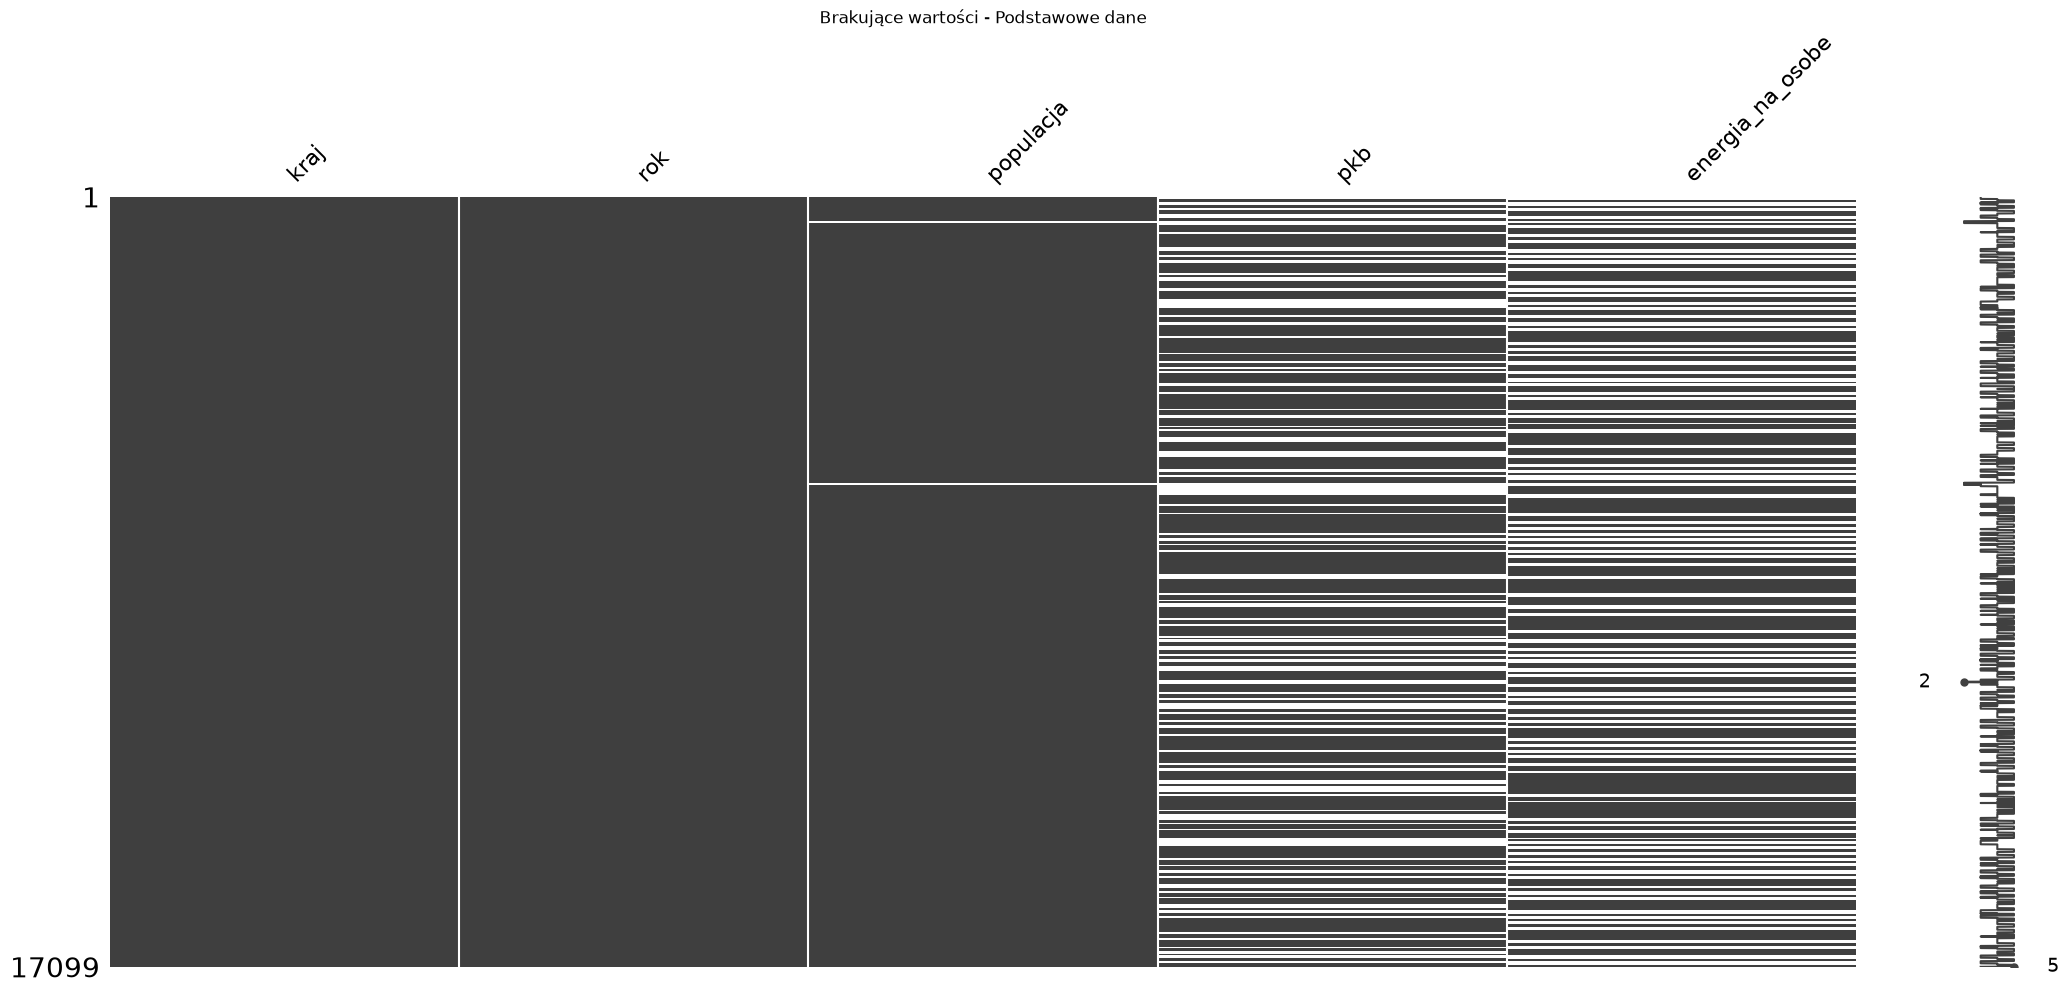

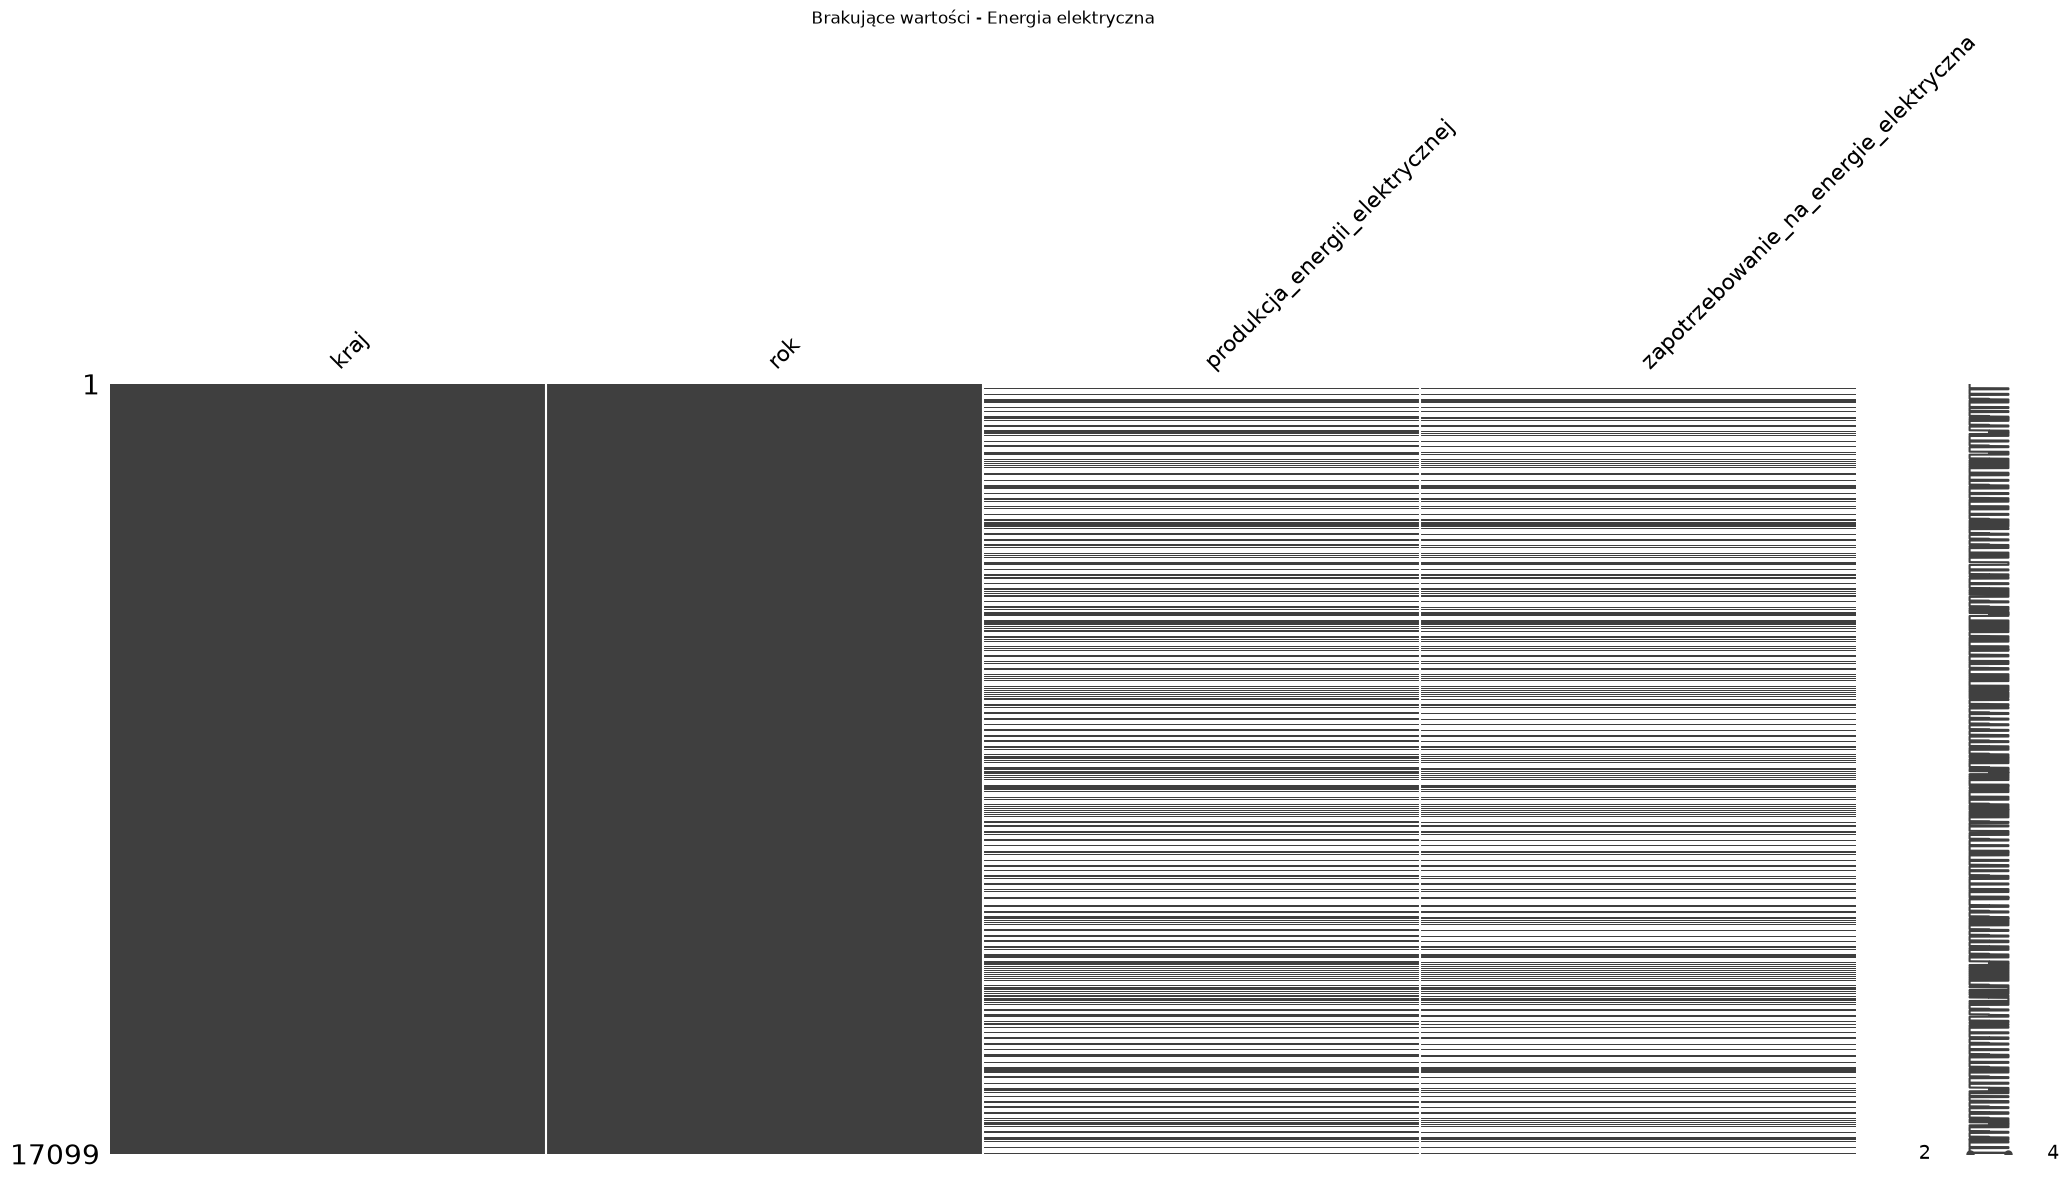

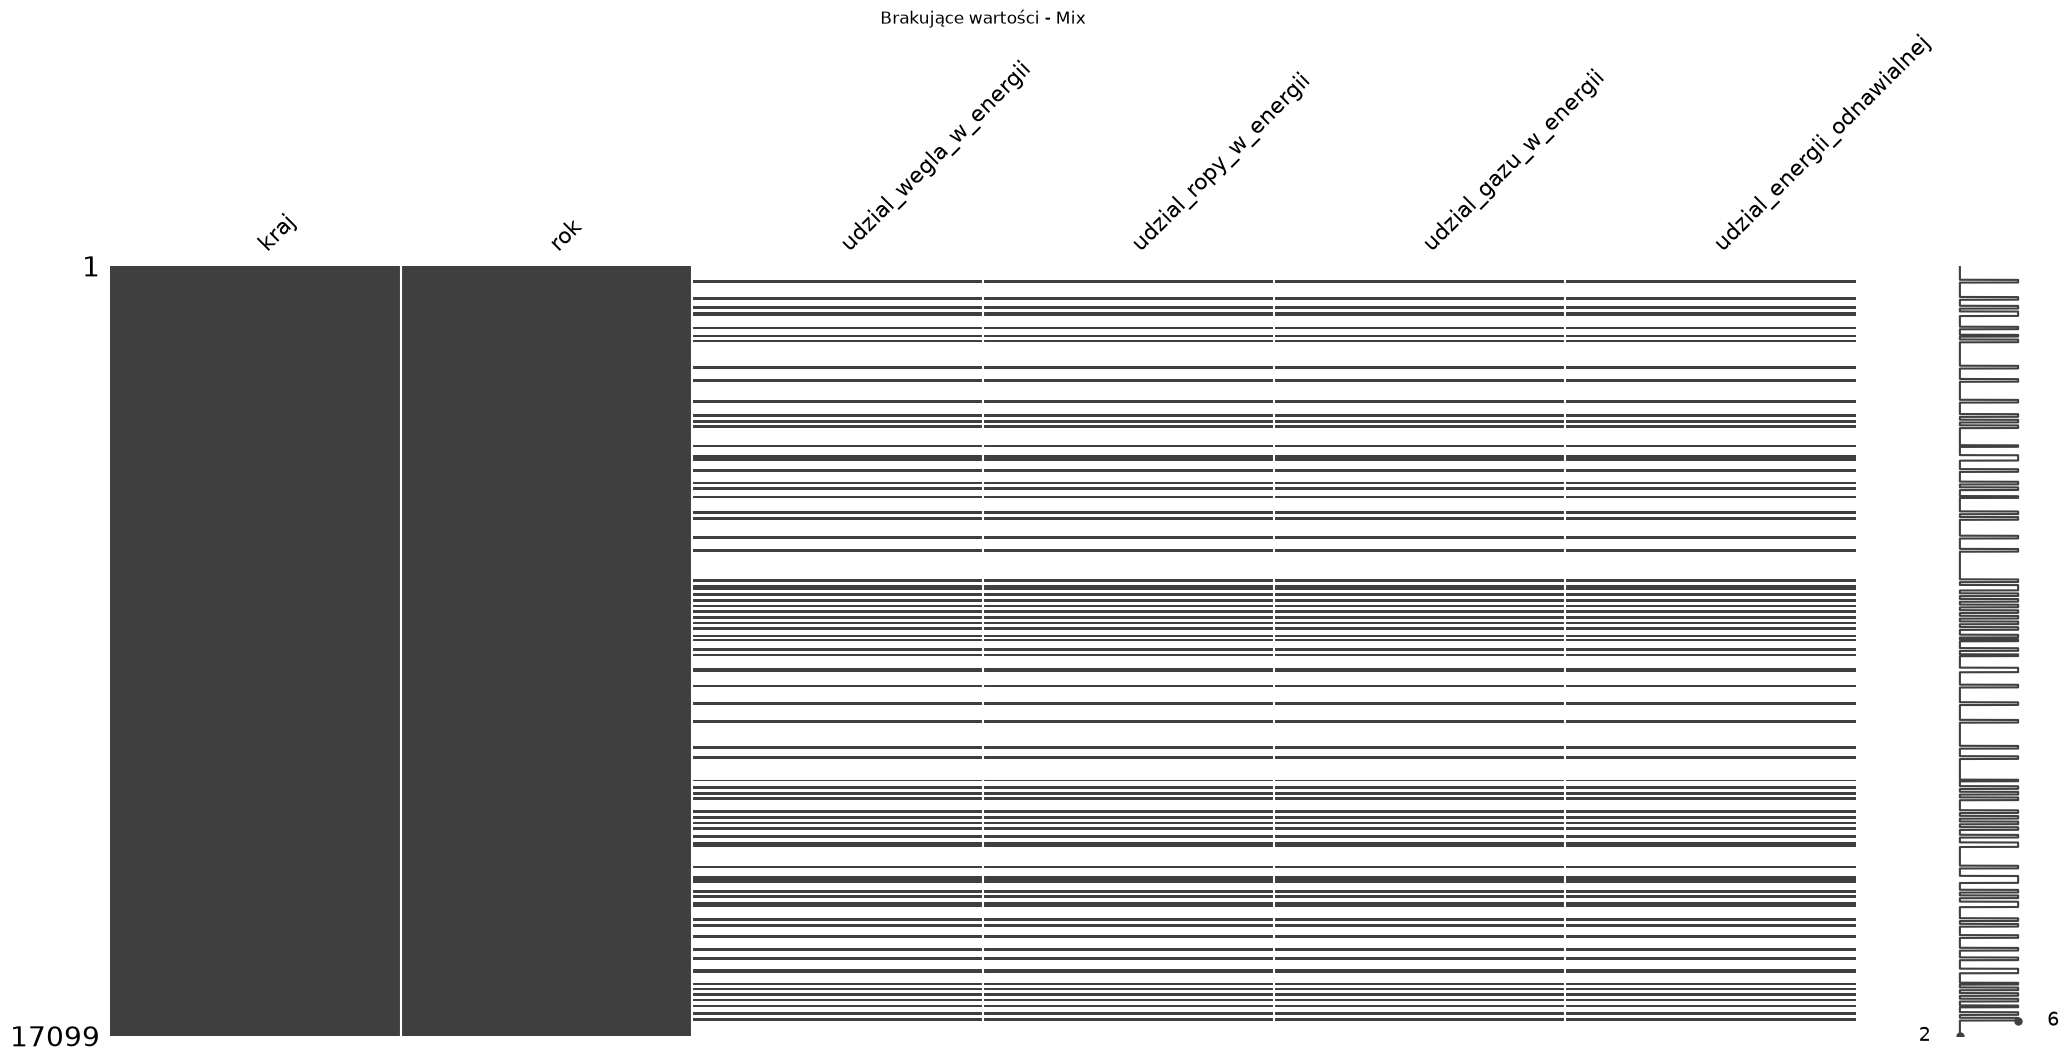

In [28]:
#Creating shadow maps of missing values
msno.matrix(basic)
plt.title("Brakujące wartości - Podstawowe dane")
plt.show()
msno.matrix(electricity)
plt.title("Brakujące wartości - Energia elektryczna")
plt.show()
msno.matrix(mix)
plt.title("Brakujące wartości - Mix")
plt.show()

Shadow mapy przedstawiają rozmieszczenie brakujących wartości w analizowanych zbiorach danych. We wszystkich trzech macierzach kolumny country oraz year są kompletne i nie zawierają brakujących obserwacji.

Macierz Basic obejmuje podstawowe zmienne: country, year, population, gdp oraz energy_per_capita. Analiza wykazała, że zmienna population zawiera jedynie nieliczne braki. Największa liczba brakujących wartości występuje w kolumnach gdp (Gross Domestic Product) oraz energy_per_capita. Braki te są rozproszone w całym zbiorze danych.

Macierz Electricity przedstawia dane dotyczące produkcji i zapotrzebowania na energię elektryczną. Zarówno electricity_generation, jak i electricity_demand zawierają znaczną liczbę brakujących wartości, przy czym ich rozmieszczenie jest niemal identyczne. Oznacza to, że informacje dotyczące produkcji oraz zapotrzebowania na energię elektryczną były raportowane równocześnie. Jeżeli dla danego kraju lub roku brakowało jednej z tych wartości, najczęściej brakowało również drugiej.

Macierz Mix przedstawia udział poszczególnych źródeł energii w miksie energetycznym (coal_share_energy, oil_share_energy, gas_share_energy oraz renewables_share_energy). Wszystkie analizowane wskaźniki charakteryzują się niemal identycznym wzorcem braków. Brakujące wartości występują jednocześnie we wszystkich zmiennych, co oznacza, że dla części obserwacji dostępny jest kompletny zestaw danych, natomiast dla pozostałych nie jest dostępna żadna z analizowanych informacji. Taki rozkład sugeruje, że dane dotyczące struktury miksu energetycznego były udostępniane jako spójny zestaw, a ich brak wynika z niedostępności danych dla określonych krajów lub lat.

Podsumowanie

Analiza shadow map wskazuje, że brakujące wartości nie są rozmieszczone losowo. Zmienne należące do tej samej grupy tematycznej wykazują bardzo podobny wzorzec braków, co sugeruje ich wspólne źródło. Najiększa liczba braków dotyczy szczegółowych danych mixu energetycznego.

Strategia postępowania z brakującymi danymi

Ponieważ większość braków wynika z ograniczonej dostępności danych historycznych, zrezygnowano z imputacji brakujących wartości. Uzupełnianie ich mogłoby prowadzić do zniekształcenia wyników analizy i błędnej interpretacji trendów. W dalszej części projektu wykorzystano wyłącznie obserwacje zawierające wartości dla zmiennych niezbędnych do realizacji postawionych pytań badawczych.

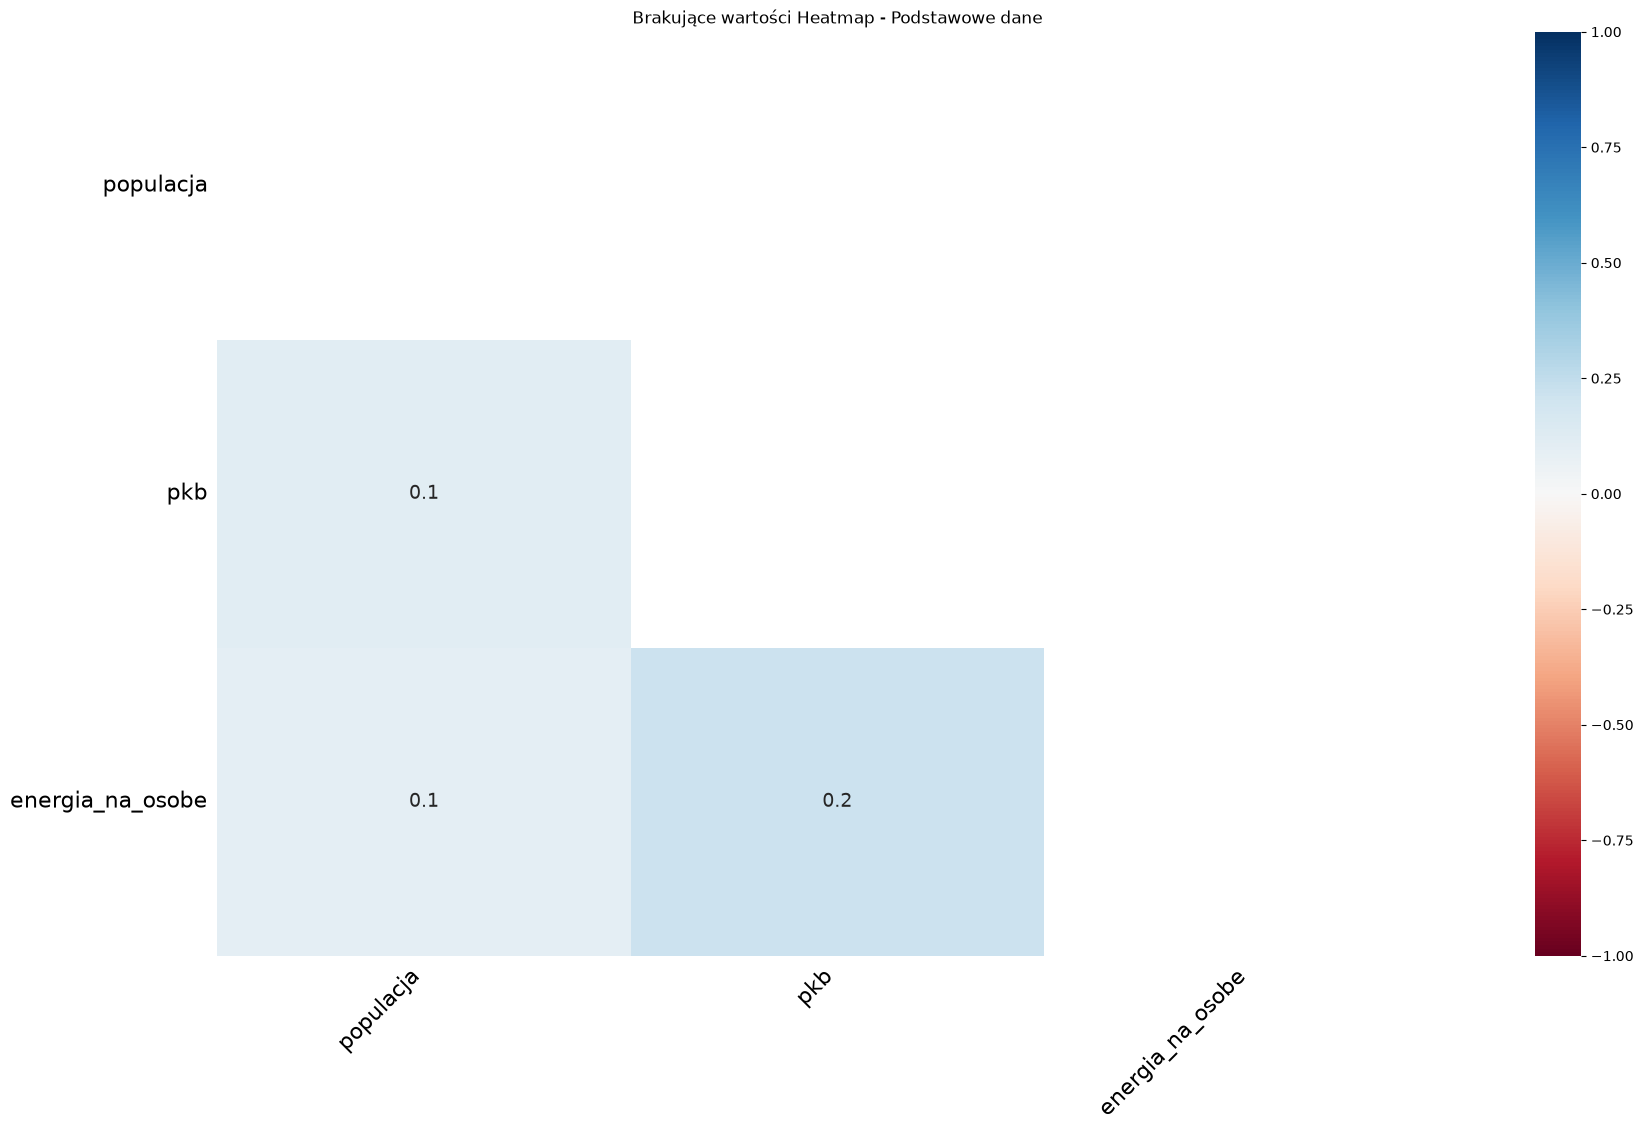

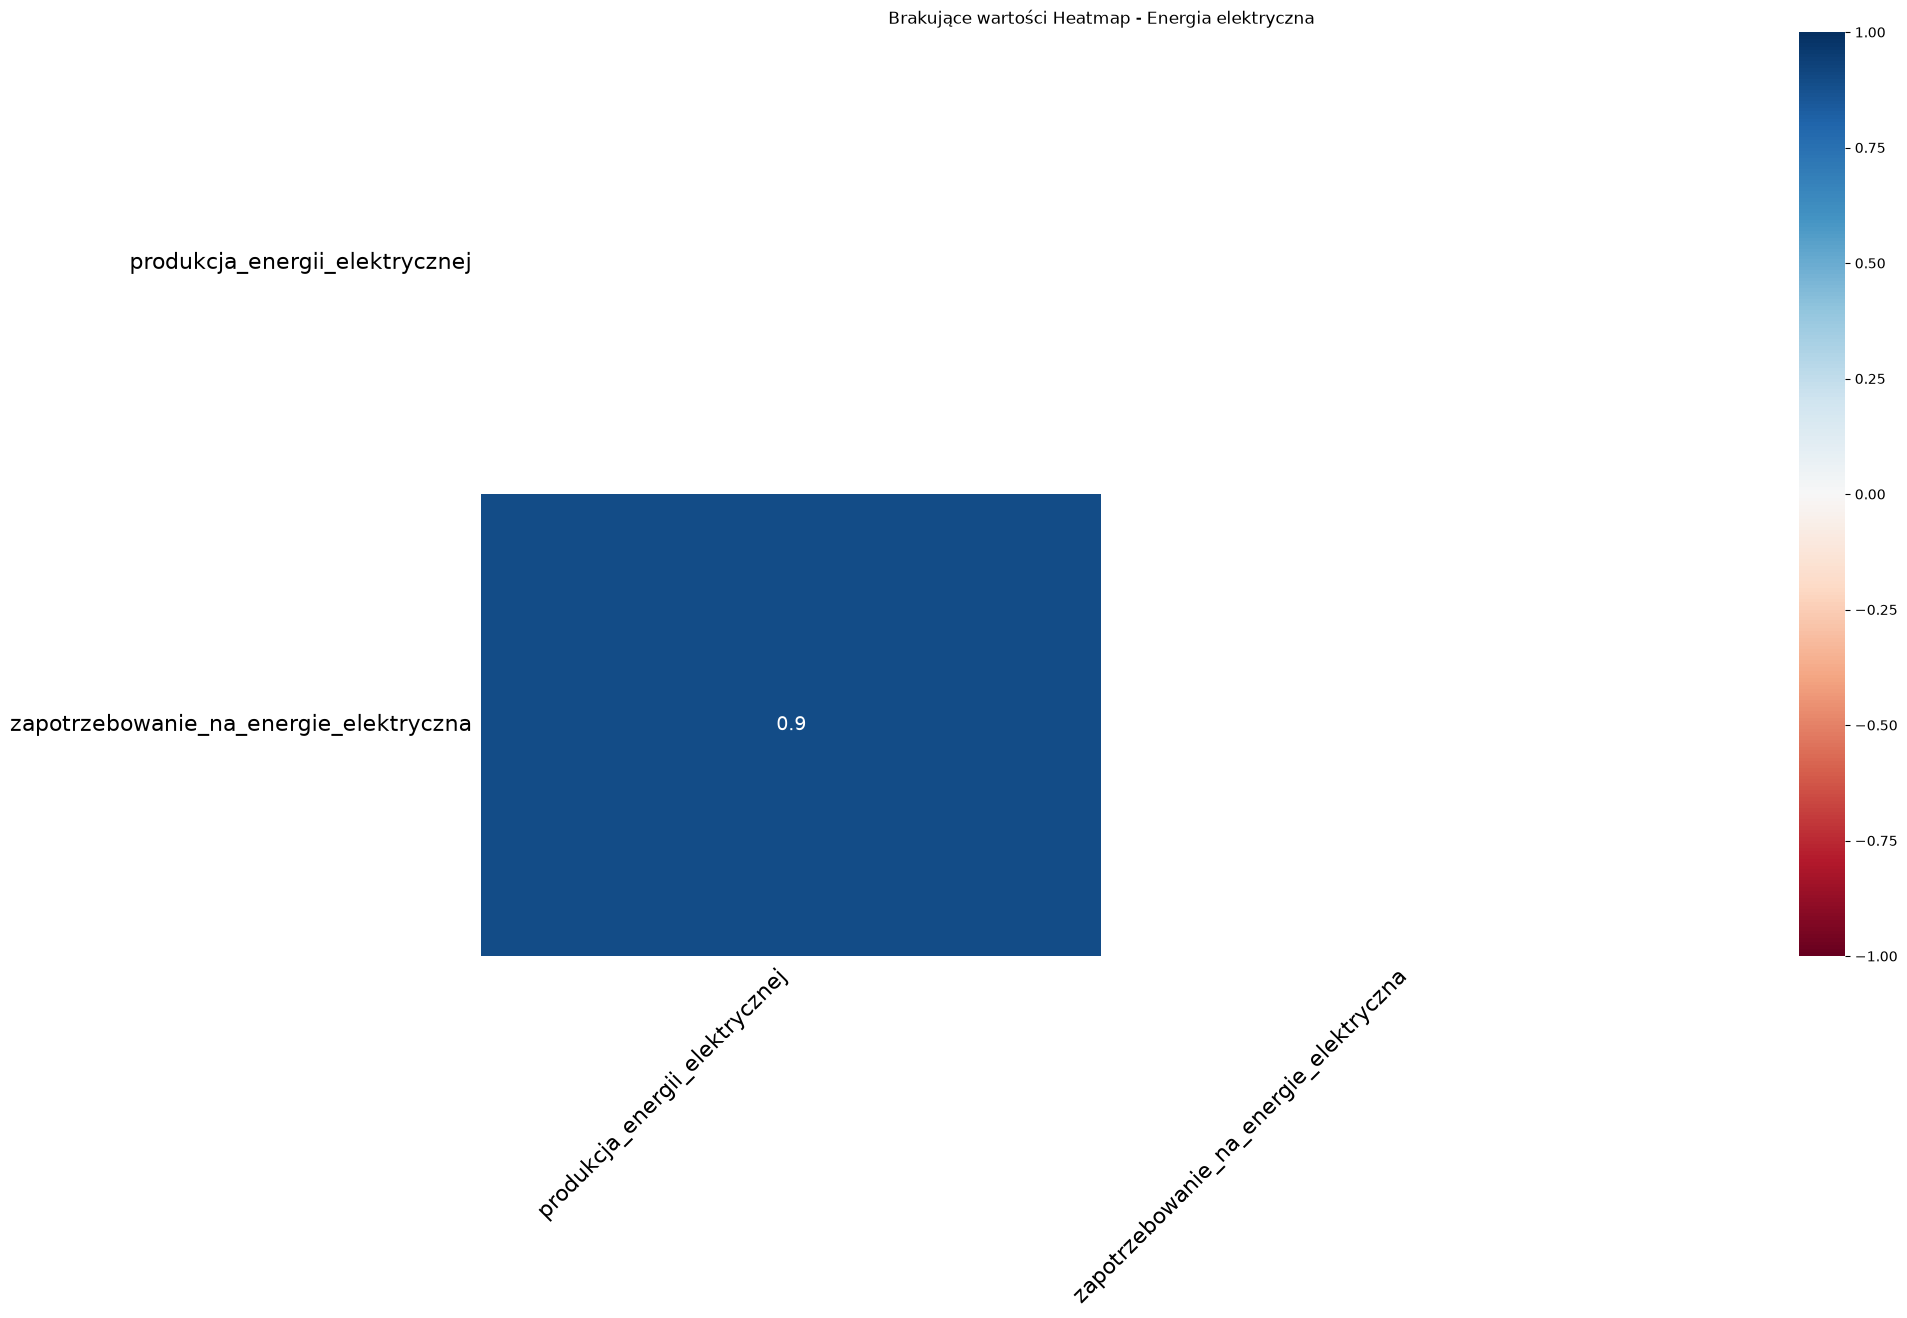

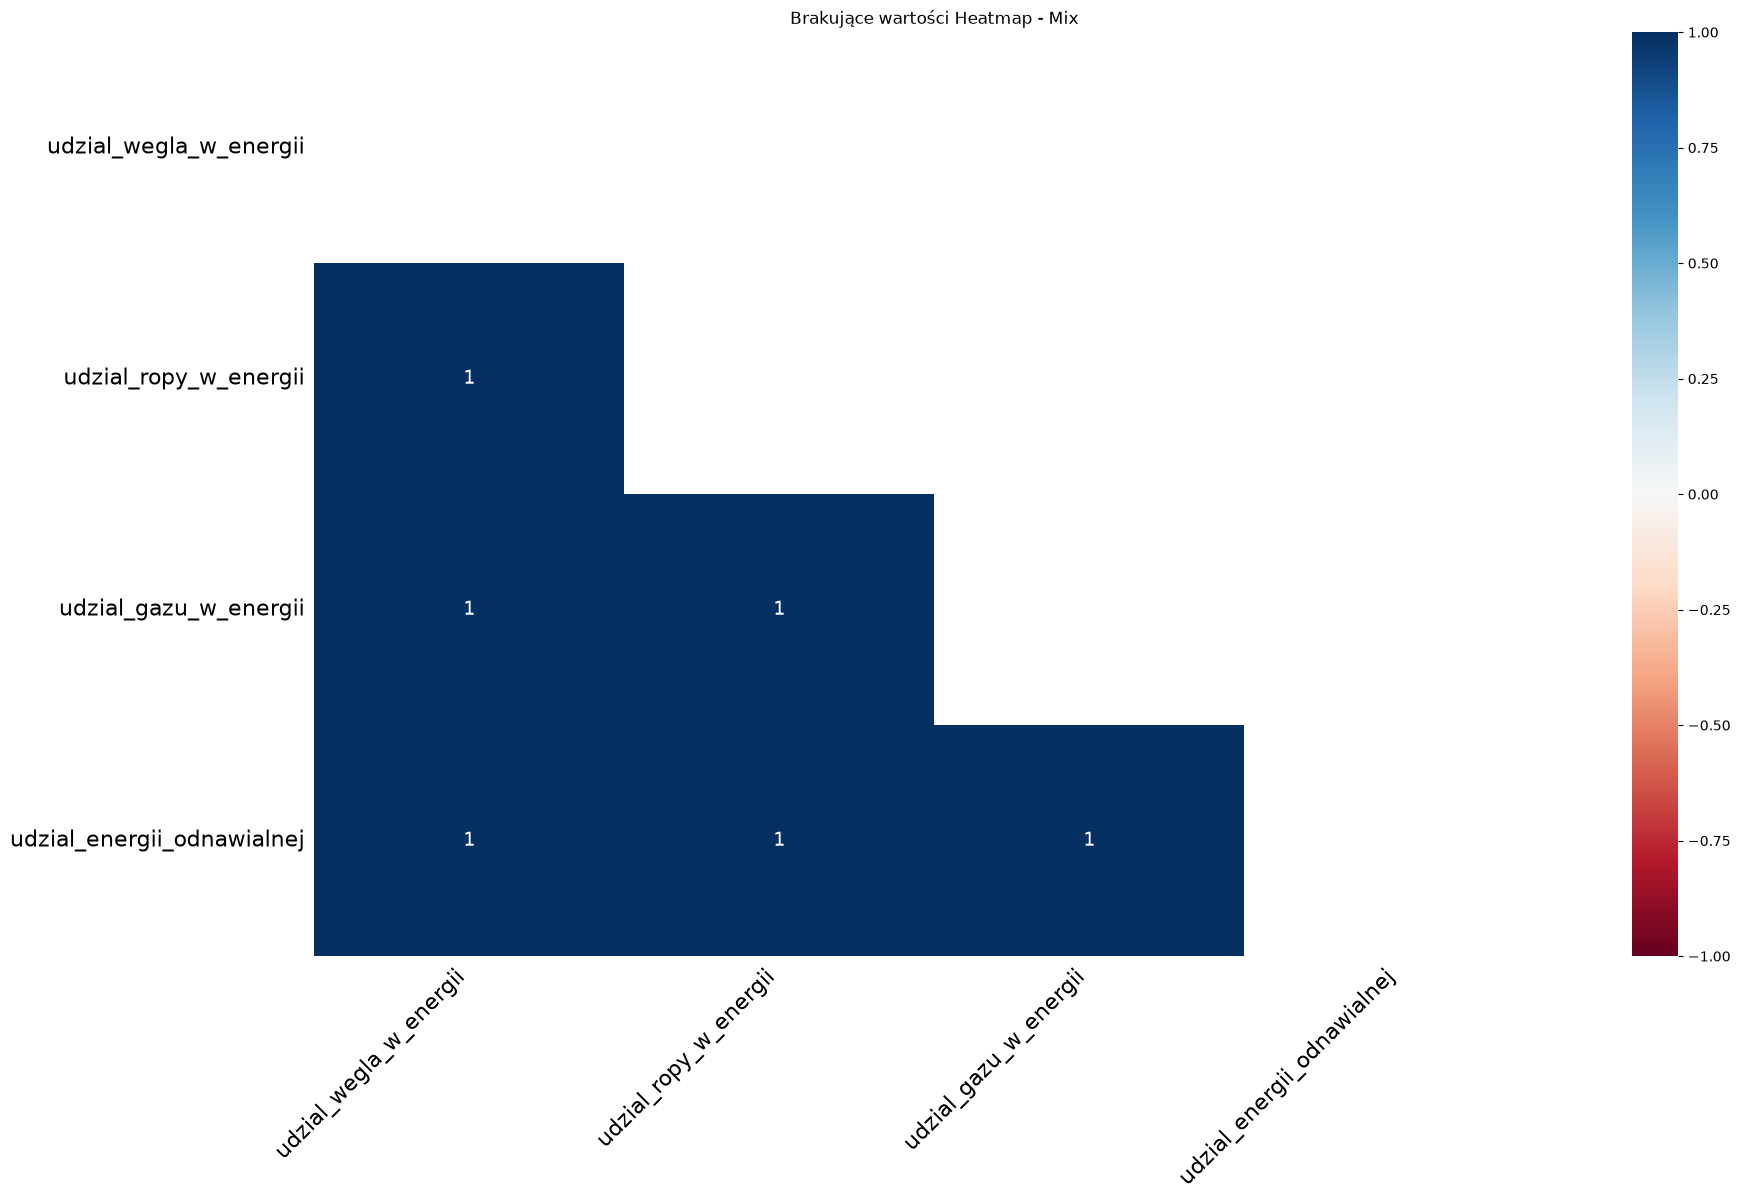

In [29]:
#Heat map analysis of missing values
msno.heatmap(basic)
plt.title("Brakujące wartości Heatmap - Podstawowe dane")
plt.show()
msno.heatmap(electricity)
plt.title("Brakujące wartości Heatmap - Energia elektryczna")
plt.show()
msno.heatmap(mix)
plt.title("Brakujące wartości Heatmap - Mix")
plt.show()

Heatmapy przedstawiają stopień współwystępowania brakujących wartości pomiędzy analizowanymi zmiennymi. Wartości na mapach odpowiadają korelacji braków danych – im bliższa wartość 1, tym częściej braki występują jednocześnie w porównywanych zmiennych.

Heatmapa Basic obejmuje zmienne: population, gdp oraz energy_per_capita. Analiza wskazuje na stosunkowo słabą zależność pomiędzy brakami danych w tych zmiennych. Oznacza to, że brak wartości w jednej kolumnie nie musi oznaczać jednoczesnego braku danych w pozostałych zmiennych. Braki mają charakter bardziej niezależny i nie tworzą wyraźnego wspólnego wzorca.

Heatmapa Electricity przedstawia zależność pomiędzy zmiennymi electricity_generation oraz electricity_demand. Uzyskana wartość korelacji braków wynosząca około 0,9 wskazuje na bardzo silną zgodność ich występowania. Oznacza to, że brak danych dotyczących produkcji energii elektrycznej w większości przypadków wiąże się również z brakiem informacji o zapotrzebowaniu na energię elektryczną. Sugeruje to, że obie zmienne pochodzą z tego samego źródła danych i były raportowane równocześnie.

Heatmapa Mix obejmuje zmienne opisujące udział poszczególnych źródeł energii w miksie energetycznym (coal_share_energy, oil_share_energy, gas_share_energy oraz renewables_share_energy). Wszystkie pary zmiennych osiągają współczynnik korelacji braków równy 1,0, co oznacza pełną zgodność wzorca brakujących danych. W praktyce oznacza to, że jeżeli dla danej obserwacji brakuje informacji o udziale jednego źródła energii, to jednocześnie brakuje danych dla wszystkich pozostałych zmiennych opisujących miks energetyczny. Świadczy to o tym, że dane dotyczące struktury miksu energetycznego były udostępniane jako kompletny zestaw informacji.

Podsumowanie

Analiza heatmap potwierdza, że brakujące wartości nie występują losowo. Zmienne należące do tej samej grupy tematycznej charakteryzują się wysoką korelacją braków danych, co wskazuje na ich wspólne źródło oraz sposób raportowania. Najsilniejszą zależność zaobserwowano dla zmiennych opisujących strukturę miksu energetycznego, gdzie współczynnik korelacji braków osiąga wartość 1,0, natomiast dla zmiennych dotyczących produkcji i zapotrzebowania na energię elektryczną wynosi około 0,9. Wyniki te są zgodne z obserwacjami uzyskanymi na podstawie shadow map i potwierdzają, że brak danych wynika przede wszystkim z niedostępności całych zestawów informacji dla określonych krajów lub lat, a nie z przypadkowych braków pojedynczych wartości.

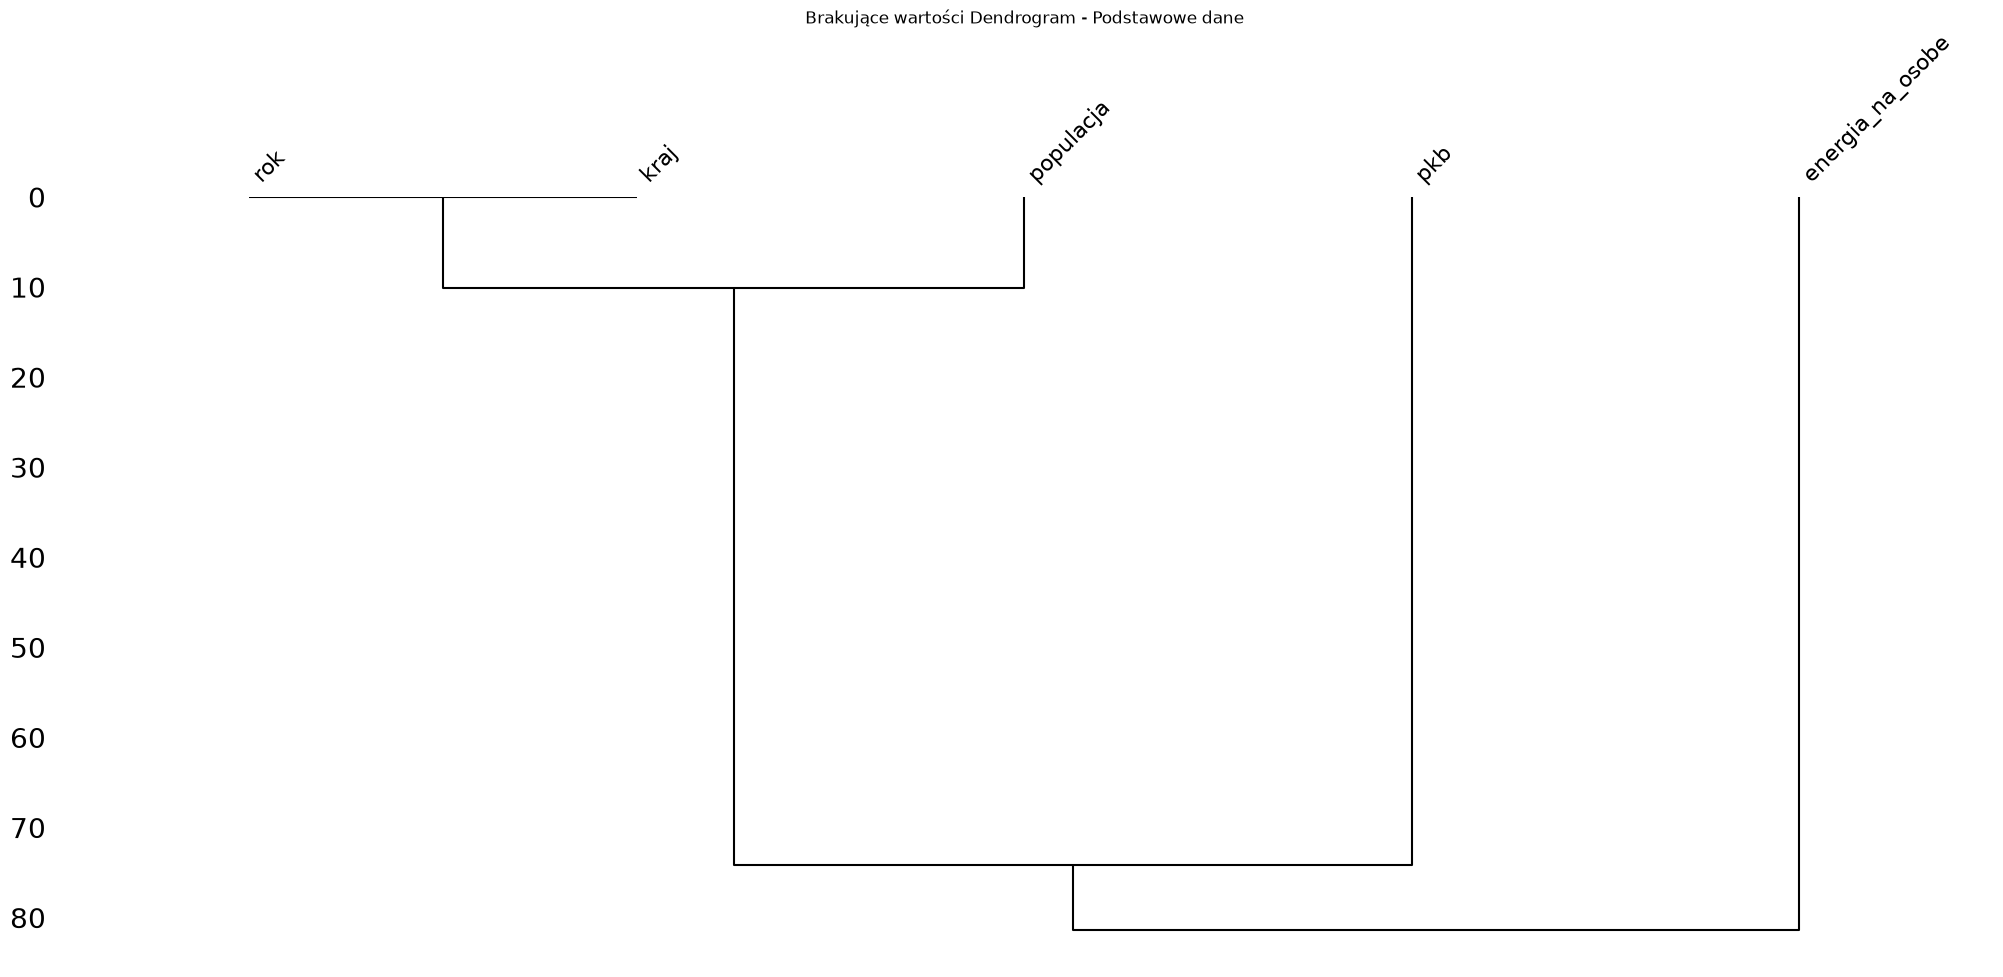

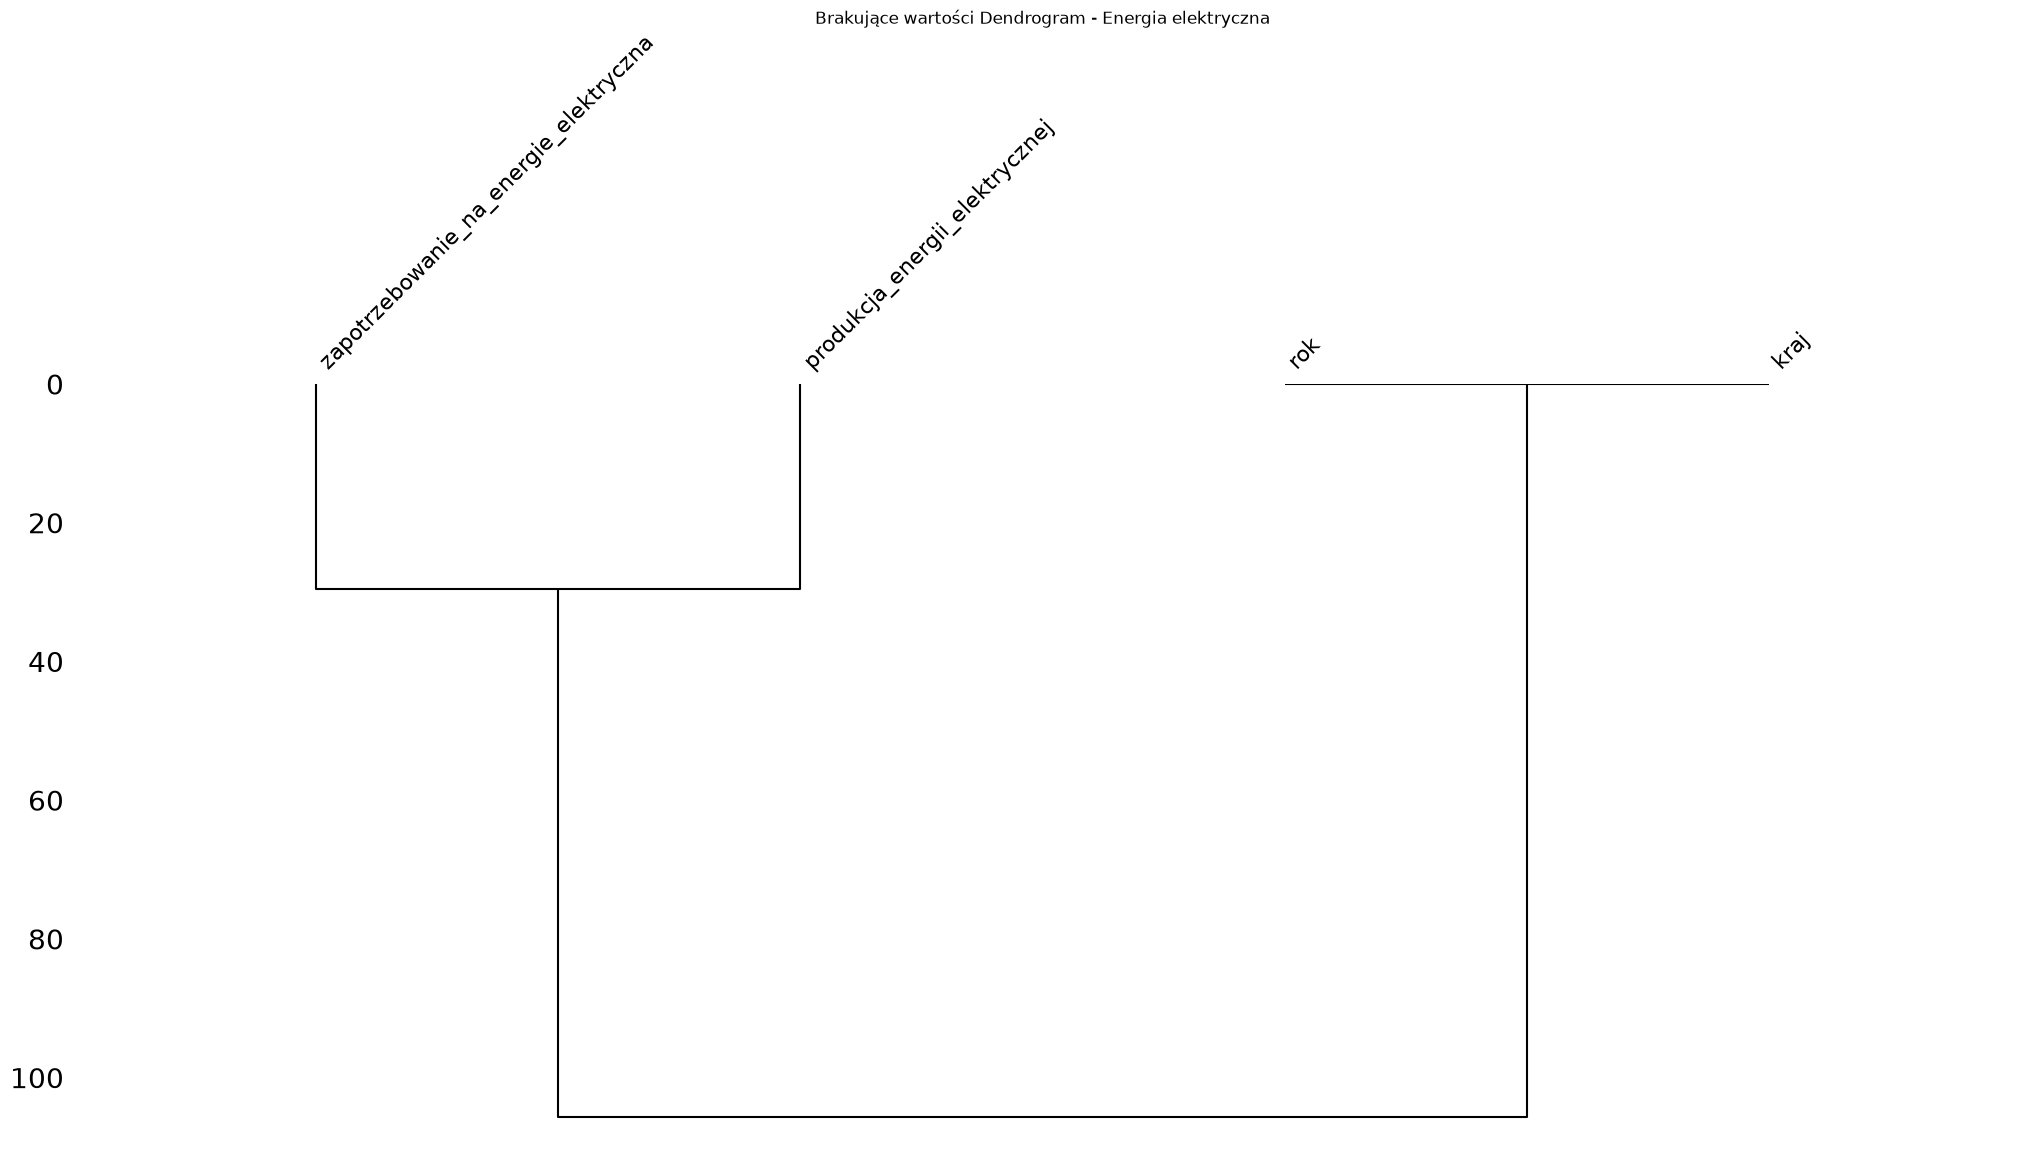

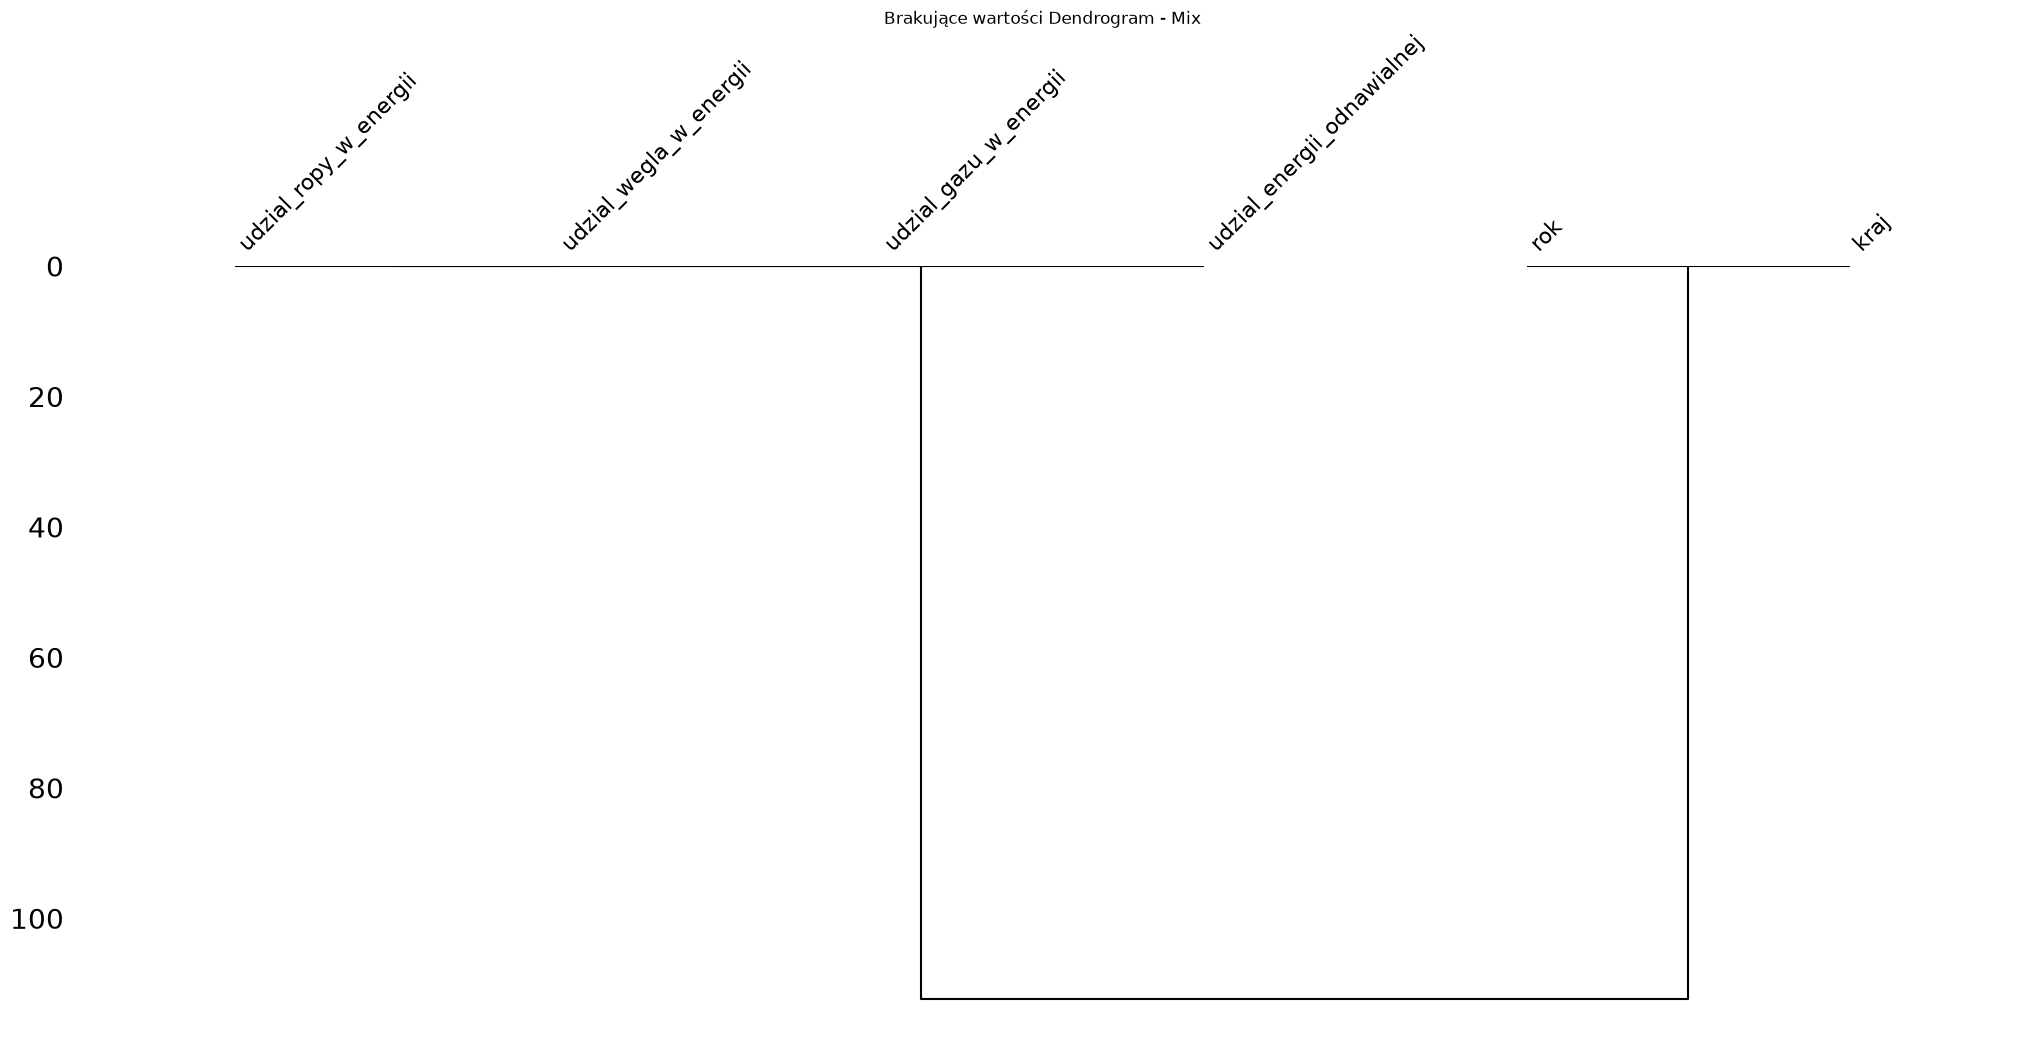

In [30]:
#dendrogram analysis of missing values
msno.dendrogram(basic)
plt.title("Brakujące wartości Dendrogram - Podstawowe dane")
plt.show()
msno.dendrogram(electricity)
plt.title("Brakujące wartości Dendrogram - Energia elektryczna")
plt.show()
msno.dendrogram(mix)
plt.title("Brakujące wartości Dendrogram - Mix")
plt.show()

Dendrogram brakujących danych przedstawia podobieństwo wzorców występowania braków pomiędzy analizowanymi zmiennymi. Zmienne połączone na niższych poziomach drzewa charakteryzują się bardziej zbliżonym rozmieszczeniem brakujących wartości, natomiast połączenia na wyższych poziomach wskazują na mniejsze podobieństwo. Analiza dendrogramów potwierdziła wyniki uzyskane na podstawie shadow map oraz heatmap. Zmienne dotyczące produkcji i zapotrzebowania na energię elektryczną tworzą wspólną grupę, co świadczy o bardzo podobnym wzorcu braków. Jeszcze silniejszą zależność zaobserwowano dla zmiennych opisujących strukturę miksu energetycznego, które zostały połączone w jedną zwartą gałąź, wskazując na niemal identyczne występowanie braków danych. Wyniki sugerują, że braki wynikają z jednoczesnej niedostępności całych zestawów informacji dla wybranych krajów lub lat, a nie z losowego braku pojedynczych obserwacji.

In [31]:
# Cleaning the datasets by dropping rows with missing values in relevant columns
basic_clean = basic.dropna(subset=["populacja", "pkb", "energia_na_osobe"])
electricity_clean = electricity.dropna(subset=["produkcja_energii_elektrycznej", "zapotrzebowanie_na_energie_elektryczna"])
mix_clean = mix.dropna(subset=["udzial_wegla_w_energii", "udzial_ropy_w_energii", "udzial_gazu_w_energii", "udzial_energii_odnawialnej"])

In [32]:
# Displaying information about the cleaned datasets
basic_clean.info()
electricity_clean.info()
mix_clean.info()

<class 'pandas.DataFrame'>
Index: 7817 entries, 105 to 23192
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   kraj              7817 non-null   str    
 1   rok               7817 non-null   int64  
 2   populacja         7817 non-null   float64
 3   pkb               7817 non-null   float64
 4   energia_na_osobe  7817 non-null   float64
dtypes: float64(3), int64(1), str(1)
memory usage: 366.4 KB
<class 'pandas.DataFrame'>
Index: 5479 entries, 125 to 23193
Data columns (total 4 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   kraj                                    5479 non-null   str    
 1   rok                                     5479 non-null   int64  
 2   produkcja_energii_elektrycznej          5479 non-null   float64
 3   zapotrzebowanie_na_energie_elektryczna  5479 non-null   float64
dtypes: flo